#Required Libraries
numpy, opencv, ultralytics, cvzone

In [ ]:
!pip install opencv-python
!pip install numpy
!pip install ultralytics
!pip install cvzone
!pip install fastapi
!pip install uvicorn
!pip install requests
!pip install kafka-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of zone to determine which version is compatible with other requirements. This could take a while.
ERROR: Ignored the following versions that require a different python version: 3.1.1.post1 Requires-Python >=2.6, <3; 3.2.0 Requires-Python >=2.6, <3; 3.3.0 Requires-Python >=2.6, <3; 3.4.0 Requires-Python >=2.6, <3
ERROR: Could not find a version that satisfies the requirement kids==0.7.6 (from zone) (from versions: 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.0.4)
ERROR: No matching distribution found for kids==0.7.6


In [6]:
!pip install confluent-kafka

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 53.5 MB/s eta 0:00:00


#Imports at the start

In [11]:
import cv2
import json
import os
import numpy as np
from ultralytics import YOLO
import cvzone
from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import Video
from confluent_kafka import Producer
import base64
from IPython.display import display, HTML
from google.colab import output
from fastapi import FastAPI
from kafka import KafkaProducer
from pydantic import BaseModel
import time
import threading
import requests

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


**UPLOAD**

Video for testing and best.pt

In [14]:
uploaded = files.upload()

Saving best.pt to best.pt


In [13]:
uploaded1 = files.upload()

Saving vid1.mp4 to vid1.mp4


MODEL YOLOv8n

Object to be detected vehicle

In [15]:
model = YOLO("best.pt")
print (model.names)

{0: 'vehicle'}


Create the producer

In [ ]:
KAFKA = os.getenv(
    "KAFKA_BOOTSTRAP_SERVERS",
    "localhost:9092"
)

TOPIC = "parking.cv.occupancy"

producer = KafkaProducer(
    bootstrap_servers=KAFKA,
    value_serializer=lambda value:
        json.dumps(value).encode("utf-8")
)

app = FastAPI(
    title="CV Parking Bridge"
)

In [22]:
producer = Producer({
    "bootstrap.servers": "localhost:9092"
})

TOPIC = "cv-parking-occupancy"

In [25]:
def delivery_report(err, msg):
    if err is not None:
        print("Kafka delivery failed:", err)
    else:
        print(
            f"Kafka message sent: "
            f"{msg.topic()} [{msg.partition()}]"
        )

In [23]:
def publish_parking_state(spot_id, occupied):

    message = {
        "spotId": spot_id,
        "state": "OCCUPIED" if occupied else "FREE",
        "source": "CV"
    }

    producer.produce(
        TOPIC,
        key=spot_id,
        value=json.dumps(message),
        callback=delivery_report
    )

    producer.poll(0)

    print("Published:", message)

Krijohet event qe do perpunohet nga consumer

In [ ]:
class CVEvent(BaseModel):
    spotId: int
    occupied: bool

Endpoint per komunikim

In [ ]:
@app.post("/cv")
def cv_event(event: CVEvent):

    payload = {
        "spotId": event.spotId,
        "occupied": event.occupied,
        "source": "CV",
        "timestamp": int(time.time() * 1000)
    }

    producer.send(
        TOPIC,
        payload
    )

    producer.flush()

    return {
        "status": "published",
        "event": payload
    }

Fillohet FASTAPI ne background

In [ ]:
import uvicorn

def run_api():

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8001
    )

api_thread = threading.Thread(
    target=run_api,
    daemon=True
)

api_thread.start()

Get the video path and opencv to get frames of the video

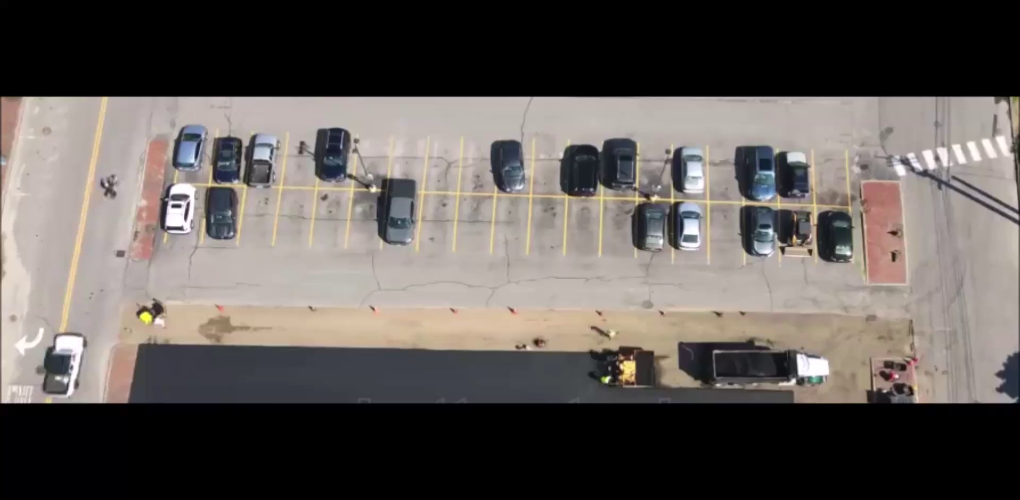

In [16]:
video_path = "vid1.mp4"

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

frame = cv2.resize(frame, (1020, 500))

cv2_imshow(frame)

cap.release()

frame = cv2.resize(frame, (650, 500))

_, buffer = cv2.imencode(".jpg", frame)

frame_base64 = base64.b64encode(buffer).decode("utf-8")

Draw the polygons in the frames instead of putting coordinates.

In [17]:
parking_spots = {}

def save_parking_spots(data):
    global parking_spots
    parking_spots = data
    print("Updated parking spots:")
    print(parking_spots)

output.register_callback(
    "parking.update",
    save_parking_spots
)


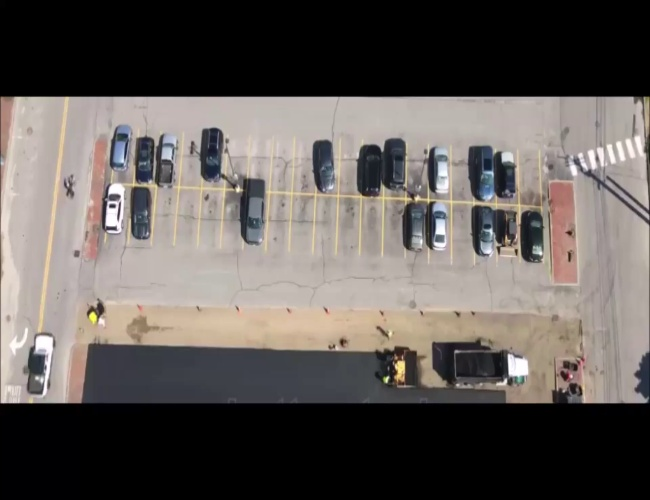

Updated parking spots:
{'CV-001': [[112, 185], [129, 191], [126, 234], [111, 233]]}
Updated parking spots:
{'CV-001': [[112, 185], [129, 191], [126, 234], [111, 233]], 'CV-002': [[137, 193], [151, 194], [148, 236], [139, 236]]}
Updated parking spots:
{'CV-001': [[112, 185], [129, 191], [126, 234], [111, 233]], 'CV-002': [[137, 193], [151, 194], [148, 236], [139, 236]], 'CV-003': [[160, 195], [172, 199], [171, 236], [160, 234]]}
Updated parking spots:
{'CV-001': [[112, 185], [129, 191], [126, 234], [111, 233]], 'CV-002': [[137, 193], [151, 194], [148, 236], [139, 236]], 'CV-003': [[160, 195], [172, 199], [171, 236], [160, 234]], 'CV-004': [[182, 194], [194, 199], [196, 240], [183, 238]]}
Updated parking spots:
{'CV-001': [[112, 185], [129, 191], [126, 234], [111, 233]], 'CV-002': [[137, 193], [151, 194], [148, 236], [139, 236]], 'CV-003': [[160, 195], [172, 199], [171, 236], [160, 234]], 'CV-004': [[182, 194], [194, 199], [196, 240], [183, 238]], 'CV-005': [[207, 200], [220, 202], [219,

In [18]:
html = f"""
<div>
    <h3>Click 4 corners of each parking space</h3>

    <p>
        Click order:
        Top Left →
        Top Right →
        Bottom Right →
        Bottom Left
    </p>

    <canvas id="parkingCanvas"
            width="650"
            height="500"
            style="border:2px solid black; cursor:crosshair;">
    </canvas>

    <br><br>

    <button onclick="saveSpot()">
        Save Parking Spot
    </button>

    <button onclick="undoPoint()">
        Undo Last Point
    </button>

    <button onclick="clearCurrent()">
        Clear Current Points
    </button>

    <button onclick="resetEverything()">
        Reset Everything
    </button>

    <p id="info"></p>
</div>

<script>

window.parkingSpots = {{}};
window.currentPoints = [];
window.spotNumber = 1;

const canvas = document.getElementById("parkingCanvas");
const ctx = canvas.getContext("2d");

const img = new Image();

img.onload = function() {{
    redraw();
}};

img.src = "data:image/jpeg;base64,{frame_base64}";


function redraw() {{

    ctx.clearRect(
        0,
        0,
        canvas.width,
        canvas.height
    );

    ctx.drawImage(
        img,
        0,
        0,
        canvas.width,
        canvas.height
    );


    // Draw saved parking spots

    for (const [spotId, points] of Object.entries(window.parkingSpots)) {{

        ctx.beginPath();

        ctx.moveTo(
            points[0][0],
            points[0][1]
        );

        for (let i = 1; i < points.length; i++) {{

            ctx.lineTo(
                points[i][0],
                points[i][1]
            );
        }}

        ctx.closePath();

        ctx.strokeStyle = "lime";
        ctx.lineWidth = 3;
        ctx.stroke();

        ctx.fillStyle = "lime";
        ctx.font = "18px Arial";

        ctx.fillText(
            spotId,
            points[0][0],
            points[0][1] - 8
        );
    }}


    // Draw currently selected points

    for (let i = 0; i < window.currentPoints.length; i++) {{

        let p = window.currentPoints[i];

        ctx.beginPath();

        ctx.arc(
            p[0],
            p[1],
            6,
            0,
            2 * Math.PI
        );

        ctx.fillStyle = "red";
        ctx.fill();

        ctx.fillStyle = "yellow";
        ctx.font = "16px Arial";

        ctx.fillText(
            (i + 1).toString(),
            p[0] + 8,
            p[1]
        );
    }}


    // connect current points

    if (window.currentPoints.length > 1) {{

        ctx.beginPath();

        ctx.moveTo(
            window.currentPoints[0][0],
            window.currentPoints[0][1]
        );

        for (let i = 1; i < window.currentPoints.length; i++) {{

            ctx.lineTo(
                window.currentPoints[i][0],
                window.currentPoints[i][1]
            );
        }}

        ctx.strokeStyle = "red";
        ctx.lineWidth = 2;
        ctx.stroke();
    }}


    document.getElementById("info").innerHTML =
        "Current points: "
        + window.currentPoints.length
        + "/4"
        + " | Next spot: CV-"
        + String(window.spotNumber).padStart(3, "0");
}}


canvas.addEventListener("click", function(event) {{

    if (window.currentPoints.length >= 4) {{

        alert(
            "You already selected 4 points. Click Save Parking Spot."
        );

        return;
    }}

    const rect = canvas.getBoundingClientRect();

    const x = Math.round(
        (event.clientX - rect.left)
        * canvas.width
        / rect.width
    );

    const y = Math.round(
        (event.clientY - rect.top)
        * canvas.height
        / rect.height
    );

    window.currentPoints.push([x, y]);

    redraw();
}});


function saveSpot() {{

    if (currentPoints.length !== 4) {{
        alert("Select exactly 4 points.");
        return;
    }}

    const id =
        "CV-" +
        String(spotNumber).padStart(3, "0");

    parkingSpots[id] = [...currentPoints];

    google.colab.kernel.invokeFunction(
        "parking.update",
        [parkingSpots],
        {{}}
    );

    currentPoints = [];
    spotNumber++;

    redraw();
}}


function clearCurrent() {{

    window.currentPoints = [];

    redraw();
}}


function resetEverything() {{

    window.parkingSpots = {{}};

    window.currentPoints = [];

    window.spotNumber = 1;

    redraw();
}}


</script>
"""

display(HTML(html))

Put bounding boxes and analyze occupancy

In [26]:
cap = cv2.VideoCapture(video_path)

width = 650
height = 500

fps = cap.get(cv2.CAP_PROP_FPS)

out = cv2.VideoWriter("parking_output.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

previous_states = {}

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame = cv2.resize(frame, (width, height))

    results = model.track(frame,verbose=False)

    occupied = {
        spot_id: False
        for spot_id in parking_spots
    }

    if results[0].boxes is not None:

        boxes = results[0].boxes.xyxy.cpu().numpy().astype(int)

        for box in boxes:

            x1, y1, x2, y2 = box

            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (255, 0, 255),
                2
            )

            cv2.circle(
                frame,
                (cx, cy),
                5,
                (255, 0, 255),
                -1
            )

            for spot_id, polygon in parking_spots.items():

                pts = np.array(
                    polygon,
                    np.int32
                ).reshape((-1, 1, 2))

                inside = cv2.pointPolygonTest(
                    pts,
                    (cx, cy),
                    False
                )

                if inside >= 0:
                    occupied[spot_id] = True

    for spot_id, is_occupied in occupied.items():

        if (
            spot_id not in previous_states
            or previous_states[spot_id] != is_occupied
        ):

            publish_parking_state(
                spot_id,
                is_occupied
            )

            previous_states[spot_id] = is_occupied

    for spot_id, polygon in parking_spots.items():

        pts = np.array(
            polygon,
            np.int32
        ).reshape((-1, 1, 2))

        if occupied[spot_id]:
            color = (0, 0, 255)
            text = "OCCUPIED"
        else:
            color = (0, 255, 0)
            text = "FREE"

        cv2.polylines(
            frame,
            [pts],
            True,
            color,
            3
        )

        x, y = polygon[0]

        cv2.putText(
            frame,
            f"{spot_id} {text}",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

    occupied_count = sum(occupied.values())
    total = len(parking_spots)
    free_count = total - occupied_count

    out.write(frame)

cap.release()
out.release()

print("DONE")

Published: {'spotId': 'CV-001', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-002', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-003', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-004', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-005', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-006', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-007', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-002', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-004', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-004', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-004', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-005', 'state': 'OCCUPIED', 'source': 'CV'}
Published: {'spotId': 'CV-005', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-001', 'state': 'FREE', 'source': 'CV'}
Published: {'spotId': 'CV-001', 'state': 'OCCUPIED', 'source': 'CV

In [28]:
!ffmpeg -y -i parking_output.mp4 -vcodec libx264 parking_output_fixed.mp4

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [29]:
Video(
    "parking_output_fixed.mp4",
    embed=True,
    width=800
)